# 11 · Wrap-up and take-homes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/project-delphi/tensors-workshop/blob/main/notebooks/11-wrap-up-and-take-homes.ipynb)

*wrap-up · 5 min + take-homes after the workshop*

> 🇪🇸 **Cierre y ejercicios para casa** — Resume la idea que conecta el taller y luego elige entre cinco extensiones: PCA, atención, CP, Cholesky y audio.

Wrap up the workshop around one connecting idea, then choose among five extensions: PCA, attention, CP, Cholesky, and audio.

## What you will be able to do

- State the approximation idea connecting pseudoinverse, deconvolution, and Tucker.
- Diagnose the scaling trap in PCA on real breast-cancer measurements.
- Build masked attention from two `einsum` contractions.
- Compare CP with Tucker on the same real New York taxi tensor.
- Use Cholesky to turn independent noise into correlated draws and quantify the portfolio consequence.
- Denoise a real voice recording with STFT → truncated SVD → ISTFT and measure the SNR trade-off.

> 🇪🇸 **Al terminar podrás:** conectar pseudoinversa, deconvolución y Tucker mediante la idea de aproximación estable; detectar el problema de escala en PCA; construir atención enmascarada; comparar CP y Tucker; simular correlación con Cholesky; y medir una reducción de ruido de audio basada en SVD.

## Setup

Run this once. The live five-minute wrap-up only needs the summary below; the code supports the take-homes you can explore afterward.

> 🇪🇸 Ejecuta esta celda una vez. El cierre en vivo dura solo cinco minutos; el código prepara los ejercicios para casa que puedes explorar después.

In [1]:
import hashlib
import io
import subprocess
import sys
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import Audio, display
from scipy import signal
from sklearn.datasets import load_breast_cancer

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

rng = np.random.default_rng(0)

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

def snr_db(reference, estimate):
    reference = np.asarray(reference)
    estimate = np.asarray(estimate)
    return 10 * np.log10(
        np.sum(reference**2) /
        np.sum((estimate - reference)**2)
    )

print("Setup ready / Preparación lista")

Setup ready / Preparación lista


## Why this matters — one idea connects the workshop

Sections 07, 09, and 10 looked different:

- the pseudoinverse handled an overdetermined linear system;
- deconvolution tried to recover an image after blur;
- Tucker compressed a tensor into lower-dimensional mode-specific factors.

But the same decision appears in all three:

> **When an exact inverse or exact representation is unavailable, unstable, or unnecessarily expensive, choose a controlled approximation and measure what you lose.**

That sentence is the bridge from linear algebra to modern machine learning. The five take-homes below reuse it in different settings.

### How to use this notebook

Each take-home has a `TODO` cell and a folded **Solution / Solución**. Try the task first, then open the solution.

> 🇪🇸 **Una idea conecta el taller:** cuando una inversa exacta o una representación exacta no existe, es inestable o cuesta demasiado, construye una aproximación controlada y mide qué pierdes.
>
> Cada ejercicio tiene un `TODO` y una **Solution / Solución** plegada. Intenta primero; abre la solución después.

## Take-home A — PCA: the scaling trap

The Wisconsin Diagnostic Breast Cancer dataset has 30 real measurements per tumour sample, but those features use very different numerical scales.

Your goal is not merely to run PCA. It is to discover why unstandardized PCA can give a technically correct but scientifically misleading answer.

> 🇪🇸 El conjunto Wisconsin Diagnostic Breast Cancer tiene 30 mediciones reales por muestra, pero en escalas numéricas muy distintas. El reto es descubrir por qué PCA sin estandarizar puede producir una respuesta matemáticamente válida pero científicamente engañosa.

In [2]:
# TODO
# 1. Load the breast-cancer data.
# 2. Center X and compute SVD.
# 3. How many components explain 95% of variance?
# 4. Inspect feature variances. Why is the answer suspicious?
# 5. Standardize every feature and repeat.
# 6. Compare the two cumulative-variance curves.

95% components — raw / sin estandarizar: 1
95% components — standardized / estandarizado: 10
feature variance range / rango de varianzas: 6.989e-06 to / a 3.236e+05


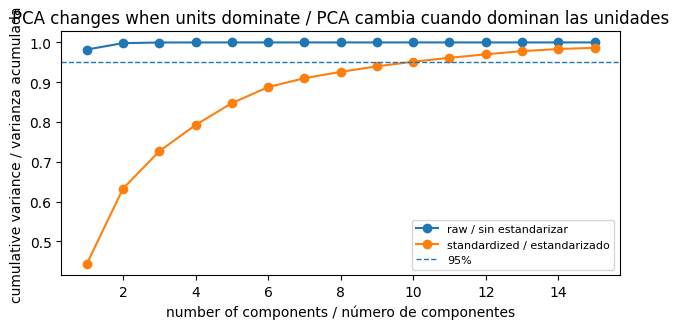

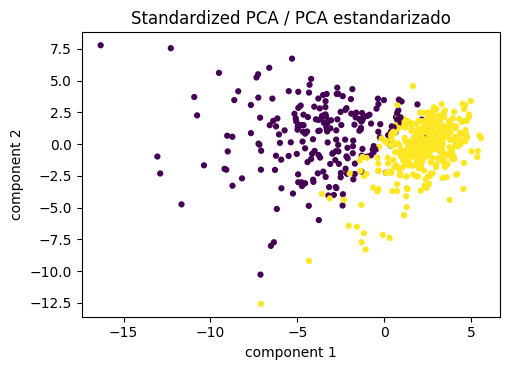

Take-away / Idea: PCA optimizes variance, not scientific relevance; scale the features when units differ.


In [3]:
#@title Solution / Solución — open after trying / abre después de intentar { display-mode: 'form' }
bc = load_breast_cancer()
X, y = bc.data, bc.target

X_centered = X - X.mean(axis=0)
_, s_raw, Vt_raw = np.linalg.svd(X_centered, full_matrices=False)
frac_raw = s_raw**2 / np.sum(s_raw**2)
n95_raw = int(np.argmax(np.cumsum(frac_raw) >= 0.95) + 1)

feature_var = X.var(axis=0)

X_std = (X - X.mean(axis=0)) / X.std(axis=0)
_, s_std, Vt_std = np.linalg.svd(X_std, full_matrices=False)
frac_std = s_std**2 / np.sum(s_std**2)
n95_std = int(np.argmax(np.cumsum(frac_std) >= 0.95) + 1)

print("95% components — raw / sin estandarizar:", n95_raw)
print("95% components — standardized / estandarizado:", n95_std)
print(
    "feature variance range / rango de varianzas:",
    f"{feature_var.min():.3e}",
    "to / a",
    f"{feature_var.max():.3e}",
)

n_show = 15
fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(
    range(1, n_show + 1),
    np.cumsum(frac_raw[:n_show]),
    marker="o",
    label="raw / sin estandarizar",
)
ax.plot(
    range(1, n_show + 1),
    np.cumsum(frac_std[:n_show]),
    marker="o",
    label="standardized / estandarizado",
)
ax.axhline(0.95, linestyle="--", linewidth=1, label="95%")
ax.set_xlabel("number of components / número de componentes")
ax.set_ylabel("cumulative variance / varianza acumulada")
ax.set_title("PCA changes when units dominate / PCA cambia cuando dominan las unidades")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Z = X_std @ Vt_std[:2].T
fig, ax = plt.subplots(figsize=(5.2, 3.8))
scatter = ax.scatter(Z[:, 0], Z[:, 1], c=y, s=12)
ax.set_xlabel("component 1")
ax.set_ylabel("component 2")
ax.set_title("Standardized PCA / PCA estandarizado")
plt.tight_layout()
plt.show()

print(
    "Take-away / Idea:",
    "PCA optimizes variance, not scientific relevance; scale the features when units differ."
)

## Take-home B — Attention is two contractions

For this exercise we deliberately use **synthetic** `Q`, `K`, and `V` arrays. That is appropriate here because the goal is to isolate the tensor mechanics of attention — shapes, contraction axes, normalization, and masking — without mixing in a tokenizer or a trained model.

Build:

1. `scores[b, i, j] = Q[b, i, :] · K[b, j, :]`
2. row-wise softmax weights
3. `output[b, i, :] = Σ_j weights[b, i, j] V[b, j, :]`
4. a padding mask that forces the last three key positions to receive zero weight.

> 🇪🇸 Aquí usamos `Q`, `K` y `V` **sintéticos a propósito**: queremos aislar la mecánica tensorial de la atención sin confundirla con tokenización o entrenamiento. Construye puntajes, softmax, salida y una máscara para padding.

In [4]:
# TODO
# 1. Create Q, K, V with shape (batch=4, seq=12, dim=16).
# 2. Compute scaled dot-product scores with einsum.
# 3. Softmax over the key-position axis.
# 4. Contract weights with V.
# 5. Mask the final 3 key positions BEFORE softmax.
# 6. Verify masked positions receive zero weight.

scores: (4, 12, 12)
weights: (4, 12, 12)
output: (4, 12, 16)
rows sum to 1 / filas suman 1: True
largest padded weight / mayor peso en padding: 0.0


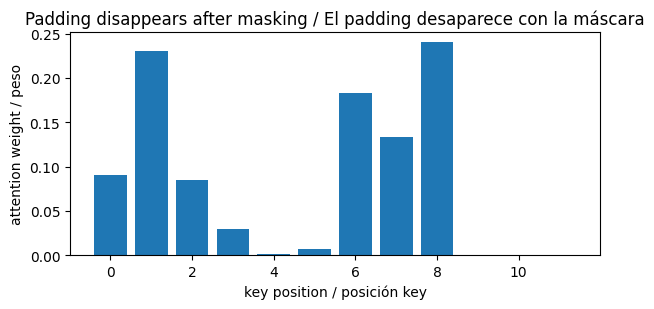

In [5]:
#@title Solution / Solución — open after trying / abre después de intentar { display-mode: 'form' }
rng_attention = np.random.default_rng(6)

batch, seq_len, dim = 4, 12, 16
Q = rng_attention.standard_normal((batch, seq_len, dim))
K = rng_attention.standard_normal((batch, seq_len, dim))
V = rng_attention.standard_normal((batch, seq_len, dim))

scores = np.einsum("bid,bjd->bij", Q, K) / np.sqrt(dim)
weights = softmax(scores, axis=-1)
attention_output = np.einsum("bij,bjd->bid", weights, V)

mask = np.zeros((seq_len, seq_len))
mask[:, -3:] = -np.inf
weights_masked = softmax(scores + mask, axis=-1)
output_masked = np.einsum("bij,bjd->bid", weights_masked, V)

print("scores:", scores.shape)
print("weights:", weights.shape)
print("output:", attention_output.shape)
print(
    "rows sum to 1 / filas suman 1:",
    np.allclose(weights_masked.sum(axis=-1), 1.0),
)
print(
    "largest padded weight / mayor peso en padding:",
    weights_masked[..., -3:].max(),
)

example = 0
query = 0

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.bar(
    range(seq_len),
    weights_masked[example, query],
)
ax.set_xlabel("key position / posición key")
ax.set_ylabel("attention weight / peso")
ax.set_title("Padding disappears after masking / El padding desaparece con la máscara")
plt.tight_layout()
plt.show()

## Take-home C — CP versus Tucker on the same real taxi tensor

Section 10 used Tucker/HOSVD. Now use **CP decomposition** on the same real `pickup borough × dropoff borough × hour` tensor.

CP represents a tensor as a sum of rank-1 outer products. Unlike Tucker, it has no separate core tensor. CP components can be individually interpretable, but uniqueness is only guaranteed under mathematical conditions — so treat patterns in this small dataset as exploratory, not as ground truth.

> 🇪🇸 La sección 10 usó Tucker/HOSVD. Ahora aplica **CP** al mismo tensor real de taxis. CP expresa el tensor como suma de productos externos de rango 1 y no usa un núcleo separado. Sus componentes pueden ser interpretables, pero la unicidad requiere condiciones matemáticas; en este conjunto pequeño, interprétalos con cautela.

In [6]:
# TODO
# 1. Rebuild the real NYC taxi tensor: pickup × dropoff × hour.
# 2. Fit a rank-3 CP decomposition with TensorLy.
# 3. Reconstruct the tensor and compute relative error.
# 4. Compare its parameter count with Tucker rank (2,2,3).
# 5. Inspect pickup, dropoff, and hour factors for each CP component.

In [7]:
#@title Solution / Solución — open after trying / abre después de intentar { display-mode: 'form' }
try:
    import tensorly as tl
    from tensorly.decomposition import parafac
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "tensorly"],
        check=True,
    )
    import tensorly as tl
    from tensorly.decomposition import parafac

TAXIS = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/taxis.csv"
taxis = pd.read_csv(TAXIS)

taxis["pickup_dt"] = pd.to_datetime(taxis["pickup"], errors="coerce")
taxis["hour"] = taxis["pickup_dt"].dt.hour

sub = taxis.dropna(
    subset=["pickup_borough", "dropoff_borough", "hour"]
).copy()
sub["hour"] = sub["hour"].astype(int)

pb = sorted(sub["pickup_borough"].unique())
db = sorted(sub["dropoff_borough"].unique())

p_idx = {name: i for i, name in enumerate(pb)}
d_idx = {name: i for i, name in enumerate(db)}

T_taxi = np.zeros((len(pb), len(db), 24), dtype=float)

for (p, d, h), count in sub.groupby(
    ["pickup_borough", "dropoff_borough", "hour"]
).size().items():
    T_taxi[p_idx[p], d_idx[d], int(h)] = float(count)

rank_cp = 3

cp_weights, cp_factors = parafac(
    tl.tensor(T_taxi),
    rank=rank_cp,
    init="svd",
    random_state=0,
    n_iter_max=500,
    tol=1e-9,
)

F_pickup, F_dropoff, F_hour = cp_factors
cp_recon = tl.cp_to_tensor((cp_weights, cp_factors))
cp_error = np.linalg.norm(cp_recon - T_taxi) / np.linalg.norm(T_taxi)

cp_params = (
    len(cp_weights)
    + sum(f.size for f in cp_factors)
)

tucker_ranks = (2, 2, 3)
tucker_params = (
    np.prod(tucker_ranks)
    + T_taxi.shape[0] * tucker_ranks[0]
    + T_taxi.shape[1] * tucker_ranks[1]
    + T_taxi.shape[2] * tucker_ranks[2]
)

print("taxi tensor / tensor taxis:", T_taxi.shape)
print("CP rank:", rank_cp)
print("CP relative error / error relativo:", f"{cp_error:.4f}")
print("CP parameters / parámetros:", int(cp_params))
print("Tucker (2,2,3) parameters / parámetros:", int(tucker_params))

component_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=rank_cp,
    step=1,
    description="Component / Componente:",
    continuous_update=False,
    style={"description_width": "145px"},
)

def show_cp_component(component):
    r = component - 1

    fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.1))

    axes[0].bar(pb, F_pickup[:, r])
    axes[0].set_title("pickup / origen")
    axes[0].tick_params(axis="x", rotation=40)

    axes[1].bar(db, F_dropoff[:, r])
    axes[1].set_title("dropoff / destino")
    axes[1].tick_params(axis="x", rotation=40)

    axes[2].bar(range(24), F_hour[:, r])
    axes[2].set_title("hour / hora")
    axes[2].set_xlabel("hour / hora")

    fig.suptitle(f"CP component / componente {component}")
    plt.tight_layout()
    plt.show()

    print(
        "strongest pickup / origen dominante:",
        pb[int(np.argmax(np.abs(F_pickup[:, r])))],
    )
    print(
        "strongest dropoff / destino dominante:",
        db[int(np.argmax(np.abs(F_dropoff[:, r])))],
    )
    print(
        "peak hour / hora pico:",
        int(np.argmax(np.abs(F_hour[:, r]))),
    )

cp_output = widgets.interactive_output(
    show_cp_component,
    {"component": component_slider},
)

display(widgets.VBox([component_slider, cp_output]))

taxi tensor / tensor taxis: (4, 5, 24)
CP rank: 3
CP relative error / error relativo: 0.0349
CP parameters / parámetros: 102
Tucker (2,2,3) parameters / parámetros: 102


## Take-home D — Cholesky builds correlation

This exercise is **synthetic by design**. We choose the covariance matrix ourselves so there is a known causal truth: the individual asset volatilities remain fixed, while only cross-asset dependence changes.

Use Cholesky `Σ = L Lᵀ` to transform independent Gaussian noise into correlated draws, then compare a correctly correlated portfolio simulation with the incorrect assumption of independence.

> 🇪🇸 Este experimento es **sintético a propósito**. Elegimos la matriz de covarianza para conocer la verdad causal: las volatilidades individuales permanecen iguales y solo cambia la dependencia entre activos. Usa Cholesky para convertir ruido independiente en muestras correlacionadas y compara ambas simulaciones.

In [8]:
# TODO
# 1. Build Sigma from volatilities and correlations.
# 2. Compute L = cholesky(Sigma) and verify L @ L.T == Sigma.
# 3. Transform independent noise z into correlated noise L @ z.
# 4. Simulate the same portfolio twice:
#    - with the correct covariance;
#    - with the same asset volatilities but zero cross-correlation.
# 5. Compare standard deviation and lower-tail percentiles.

L @ L.T == Sigma: True
covariance error / error de covarianza: 1.118966e-06
std correlated / correlacionado: 18.89
std independent / independiente: 13.61
1%, 5% correlated: [70.1  79.59]
1%, 5% independent: [79.24 86.86]


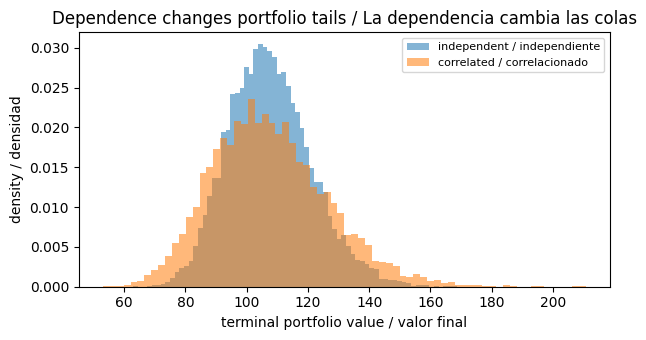

In [9]:
#@title Solution / Solución — open after trying / abre después de intentar { display-mode: 'form' }
vol = np.array([0.012, 0.015, 0.010])

corr = np.array([
    [1.00, 0.85, 0.20],
    [0.85, 1.00, 0.20],
    [0.20, 0.20, 1.00],
])

Sigma = np.outer(vol, vol) * corr
L = np.linalg.cholesky(Sigma)

print("L @ L.T == Sigma:", np.allclose(L @ L.T, Sigma))

rng_chol = np.random.default_rng(5)

z = rng_chol.standard_normal((3, 100_000))
x = L @ z

print(
    "covariance error / error de covarianza:",
    f"{np.linalg.norm(np.cov(x) - Sigma):.6e}",
)

weights_portfolio = np.array([0.4, 0.4, 0.2])
mu = np.array([0.00030, 0.00035, 0.00020])

n_days = 252
n_paths = 10_000
initial_value = 100.0

z_paths = rng_chol.standard_normal((3, n_days * n_paths))

correlated_returns = (
    mu[:, None] + L @ z_paths
).reshape(3, n_paths, n_days)

daily_corr = np.einsum(
    "a,apd->pd",
    weights_portfolio,
    correlated_returns,
)

terminal_corr = initial_value * np.prod(1 + daily_corr, axis=1)

independent_scale = np.diag(np.sqrt(np.diag(Sigma)))

independent_returns = (
    mu[:, None] + independent_scale @ z_paths
).reshape(3, n_paths, n_days)

daily_ind = np.einsum(
    "a,apd->pd",
    weights_portfolio,
    independent_returns,
)

terminal_ind = initial_value * np.prod(1 + daily_ind, axis=1)

print(
    "std correlated / correlacionado:",
    f"{terminal_corr.std():.2f}",
)
print(
    "std independent / independiente:",
    f"{terminal_ind.std():.2f}",
)
print(
    "1%, 5% correlated:",
    np.round(np.percentile(terminal_corr, [1, 5]), 2),
)
print(
    "1%, 5% independent:",
    np.round(np.percentile(terminal_ind, [1, 5]), 2),
)

fig, ax = plt.subplots(figsize=(6.3, 3.5))
ax.hist(
    terminal_ind,
    bins=70,
    density=True,
    alpha=0.55,
    label="independent / independiente",
)
ax.hist(
    terminal_corr,
    bins=70,
    density=True,
    alpha=0.55,
    label="correlated / correlacionado",
)
ax.set_xlabel("terminal portfolio value / valor final")
ax.set_ylabel("density / densidad")
ax.set_title("Dependence changes portfolio tails / La dependencia cambia las colas")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Take-home E — Audio denoising by low-rank STFT

The recording is **real**: a pinned CC0 voice sample. The added noise is **synthetic by design**, because a known clean reference lets us measure SNR objectively.

Pipeline:

**real voice → controlled noise → STFT matrix → SVD truncation → ISTFT → SNR**

The key lesson is not “SVD always removes noise.” It is that a low-rank approximation can help when the structured signal concentrates more strongly than the noise in dominant singular directions.

> 🇪🇸 La grabación es **real** y el ruido agregado es **sintético a propósito**, porque necesitamos una referencia limpia conocida para medir SNR. La lección no es que “SVD siempre elimina ruido”, sino que la aproximación de bajo rango puede ayudar cuando la señal está más concentrada que el ruido en las direcciones singulares dominantes.

In [10]:
# TODO
# 1. Download and verify the pinned voice.wav.
# 2. Add controlled Gaussian noise at 5 dB target SNR.
# 3. Compute STFT(noisy) and its complex SVD.
# 4. Try several truncation ranks k.
# 5. Reconstruct with ISTFT and measure SNR for each k.
# 6. Find the best tested k and explain why full rank returns to the noisy signal.

duration / duración: 4.949 s
measured noisy SNR / SNR ruidoso: 5.00 dB
STFT shape / forma: (513, 465)
full possible rank / rango completo: 465
best tested k / mejor k probado: 40
best SNR / mejor SNR: 9.08 dB
improvement / mejora: 4.08 dB


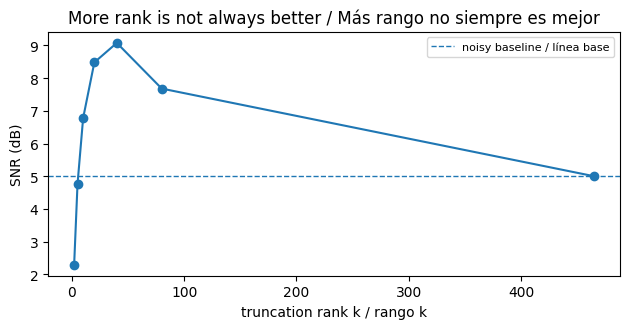

In [11]:
#@title Solution / Solución — open after trying / abre después de intentar { display-mode: 'form' }
VOICE_URL = (
    "https://raw.githubusercontent.com/pdx-cs-sound/wavs/"
    "ed5ebcbbbc2d11f0adddc9b50b78d581c29f738c/voice.wav"
)
VOICE_SHA256 = "2c4b4d9d5f90715fdbf599869a465d521638f40ca978b186df96f1543a4d67dc"

def fetch_verified_wav(url, expected_sha256):
    from scipy.io import wavfile

    raw = urllib.request.urlopen(url, timeout=30).read()
    got = hashlib.sha256(raw).hexdigest()

    if got != expected_sha256:
        raise ValueError(
            "checksum mismatch: refusing to use unverified audio"
        )

    return wavfile.read(io.BytesIO(raw))

fs, clean_i16 = fetch_verified_wav(
    VOICE_URL,
    VOICE_SHA256,
)

clean = clean_i16.astype(np.float64) / 32768.0

if clean.ndim > 1:
    clean = clean.mean(axis=1)

rng_audio = np.random.default_rng(42)

TARGET_SNR_DB = 5.0
noise = rng_audio.standard_normal(clean.shape)

noise_scale = np.sqrt(
    np.mean(clean**2) /
    (
        np.mean(noise**2)
        * 10 ** (TARGET_SNR_DB / 10)
    )
)

noisy = clean + noise_scale * noise

print(
    "duration / duración:",
    f"{len(clean) / fs:.3f} s",
)
print(
    "measured noisy SNR / SNR ruidoso:",
    f"{snr_db(clean, noisy):.2f} dB",
)

f, t, Z = signal.stft(
    noisy,
    fs=fs,
    nperseg=1024,
    noverlap=512,
)

U, s, Vh = np.linalg.svd(
    Z,
    full_matrices=False,
)

candidates = [2, 5, 10, 20, 40, 80, len(s)]

snrs = []
energies = []
reconstructions = {}

for k in candidates:
    Zk = (U[:, :k] * s[:k]) @ Vh[:k, :]

    _, x_rec = signal.istft(
        Zk,
        fs=fs,
        nperseg=1024,
        noverlap=512,
    )

    n = min(len(clean), len(x_rec))

    rec = x_rec[:n]
    ref = clean[:n]

    reconstructions[k] = rec

    snrs.append(snr_db(ref, rec))
    energies.append(
        np.sum(s[:k]**2) /
        np.sum(s**2)
    )

best_i = int(np.argmax(snrs))
best_k = candidates[best_i]

print("STFT shape / forma:", Z.shape)
print("full possible rank / rango completo:", len(s))
print("best tested k / mejor k probado:", best_k)
print("best SNR / mejor SNR:", f"{snrs[best_i]:.2f} dB")
print(
    "improvement / mejora:",
    f"{snrs[best_i] - snr_db(clean, noisy):.2f} dB",
)

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(
    candidates,
    snrs,
    marker="o",
)
ax.axhline(
    snr_db(clean, noisy),
    linestyle="--",
    linewidth=1,
    label="noisy baseline / línea base",
)
ax.set_xlabel("truncation rank k / rango k")
ax.set_ylabel("SNR (dB)")
ax.set_title("More rank is not always better / Más rango no siempre es mejor")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

rank_dropdown = widgets.Dropdown(
    options=candidates,
    value=best_k,
    description="Rank k:",
)

play_audio = widgets.Checkbox(
    value=False,
    description="Play / Reproducir",
)

audio_output = widgets.Output()

def update_audio(*_):
    with audio_output:
        audio_output.clear_output()

        k = rank_dropdown.value

        print(
            f"k={k} | retained energy / energía="
            f"{100 * energies[candidates.index(k)]:.1f}% | "
            f"SNR={snrs[candidates.index(k)]:.2f} dB"
        )

        if play_audio.value:
            rec = reconstructions[k]
            n = len(rec)
            reference = clean[:n]
            noisy_local = noisy[:n]

            peak = max(
                np.abs(reference).max(),
                np.abs(noisy_local).max(),
                np.abs(rec).max(),
            )

            print("Before / Antes")
            display(Audio(noisy_local / peak, rate=fs))

            print("After / Después")
            display(Audio(rec / peak, rate=fs))

rank_dropdown.observe(update_audio, names="value")
play_audio.observe(update_audio, names="value")

display(
    widgets.VBox([
        rank_dropdown,
        play_audio,
        audio_output,
    ])
)

update_audio()

## What just happened

The five take-homes reuse the workshop rather than introducing five unrelated tricks:

1. **PCA:** approximation can be mathematically optimal and still answer the wrong scientific question if feature scales dominate.
2. **Attention:** two tensor contractions plus normalization and masking turn pairwise similarity into a weighted combination.
3. **CP:** another tensor factorization changes the representation and interpretability trade-off relative to Tucker.
4. **Cholesky:** a factorization can be used constructively to impose a known covariance structure.
5. **Audio:** low-rank truncation is useful only when the measured approximation improves the signal criterion you care about.

### The sentence to leave with

> **Represent the structure you actually have, approximate only when you can measure the loss, and never let shape manipulation hide what the axes mean.**

The NumPy ideas transfer directly: `torch.einsum`, `tf.einsum`, and `jnp.einsum` use the same index notation, while libraries such as TensorLy provide production implementations of tensor decompositions.

> 🇪🇸 Los cinco ejercicios reutilizan la misma idea del taller. **Representa la estructura que realmente tienes, aproxima solo cuando puedes medir la pérdida y nunca permitas que una manipulación de formas oculte el significado de los ejes.**

---

## Done with this section

That is the whole workshop. Thank you for coming.

> 🇪🇸 Ese es todo el taller. Gracias por participar. Las preguntas pueden continuar en español o en inglés.

[← Back to the workshop site](https://project-delphi.github.io/tensors-workshop/) · [All notebooks](https://project-delphi.github.io/tensors-workshop/notebooks.html) · [Handbook](https://project-delphi.github.io/tensors-workshop/tensors_workshop_plan_with_quizzes.html)